In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df_dist_vs_disparity_train = pd.read_csv("./train_depth_to_disparity.csv", header=None, names=['dist_mm', 'x_disparity_px', 'y_disparity_px'])
df_depth_vs_px_width_train = pd.read_csv("./train_depth_to_px_width.csv", header=None, names=['dist_mm', 'pixel_width_mm'])
df_depth_vs_px_height_train = pd.read_csv("./train_depth_to_px_height.csv", header=None, names=['dist_mm', 'pixel_height_mm'])

df_dist_vs_disparity_test = pd.read_csv("./test_depth_to_disparity.csv", header=None, names=['dist_mm', 'x_disparity_px', 'y_disparity_px'])
df_depth_vs_px_width_test = pd.read_csv("./test_depth_to_px_width.csv", header=None, names=['dist_mm', 'pixel_width_mm'])
df_depth_vs_px_height_test = pd.read_csv("./test_depth_to_px_height.csv", header=None, names=['dist_mm', 'pixel_height_mm'])

In [30]:
def fit_reg(X_train, y_train, X_test, y_test):
    result = {}
    
    for deg in range(1,10):
        coeff = np.polyfit(X_train, y_train , deg=deg)
        # Create polynomial function
        p = np.poly1d(coeff)
        y_hat = p(X_test)
        RMSE = np.sqrt(mean_squared_error(y_test, y_hat))
        print(RMSE)
        result[RMSE] = p
        
    return result

# Fitting the polynomial to estimate depth (mm) from disparity (px). Identify the best performing degree of polynomial by evaluating against test data.

In [31]:
X_train = df_dist_vs_disparity_train['x_disparity_px']
X_test = df_dist_vs_disparity_test['x_disparity_px']
y_train = df_dist_vs_disparity_train['dist_mm']
y_test = df_dist_vs_disparity_test['dist_mm']
result = fit_reg(X_train, y_train, X_test, y_test)
best_rmse = min(result.keys())
best_p = result[best_rmse] 

857.6374323040046
1030.6482381433177
1329.3447615653265
1548.476578595345
1673.8929815051397
1713.103055655982
1680.5272189914351
1563.4752685439491
1411.441502796354


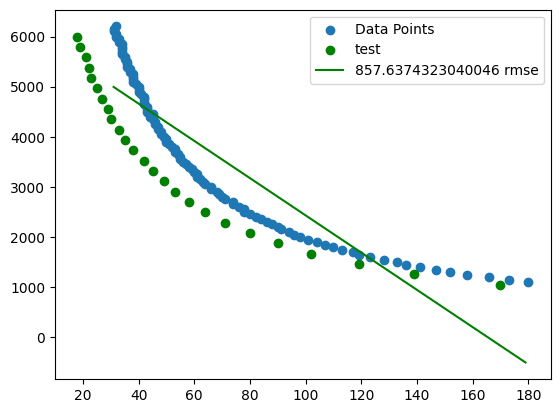

In [32]:
xp = np.arange(31, 180, 1)
plt.scatter(X_train, y_train, label='Data Points')
plt.scatter(X_test, y_test,label=f'test', color='green')                       
plt.plot(xp, best_p(xp), label=f'{best_rmse} rmse', color='green')
plt.legend()
plt.show()

# Fitting the polynomial to estimate pixel width (mm) from depth (mm). Identify the best performing degree of polynomial by evaluating against test data.

In [33]:
X_train = df_depth_vs_px_width_train['dist_mm']
X_test = df_depth_vs_px_width_test['dist_mm']
y_train = df_depth_vs_px_width_train['pixel_width_mm']
y_test = df_depth_vs_px_width_test['pixel_width_mm']
result = fit_reg(X_train, y_train, X_test, y_test)
best_rmse = min(result.keys())
best_p = result[best_rmse]

0.06764886153669461
0.06695435706347812
0.06716366535371089
0.06711243564842541
0.06637307702397784
0.06494757510353448
0.06550634215664347
0.06533476089509113
0.0656274851961866


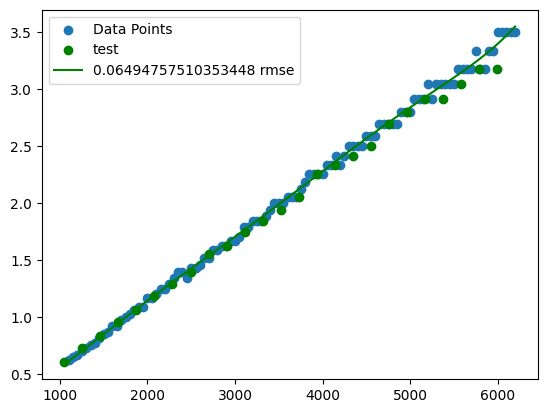

In [34]:
xp = np.arange(1100, 6200, 1)
plt.scatter(X_train, y_train, label='Data Points')
plt.scatter(X_test, y_test, label=f'test', color='green')     
plt.plot(xp, best_p(xp), label=f'{best_rmse} rmse', color='green')
plt.legend()
plt.show()

# Fitting the polynomial to estimate pixel height (mm) from depth (mm). Identify the best performing degree of polynomial by evaluating against test data.

In [35]:
X_train = df_depth_vs_px_height_train['dist_mm']
X_test = df_depth_vs_px_height_test['dist_mm']
y_train = df_depth_vs_px_height_train['pixel_height_mm']
y_test = df_depth_vs_px_height_test['pixel_height_mm']
result = fit_reg(X_train, y_train, X_test, y_test)
best_rmse = min(result.keys())
best_p = result[best_rmse]

0.09654282721539634
0.09559270140877098
0.09469223445581156
0.09481541093589782
0.09409240789209963
0.09326914080777274
0.09251254315877151
0.09307424980343303
0.09516832379943545


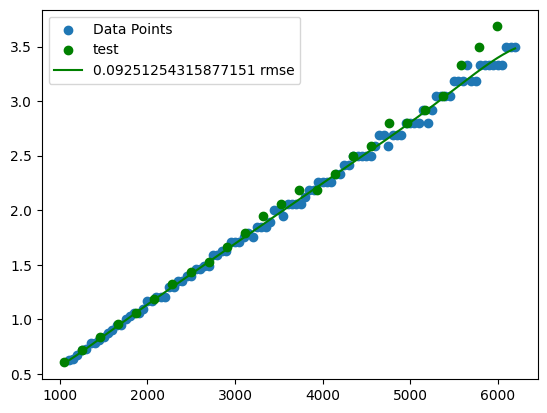

In [36]:
xp = np.arange(1100, 6200, 1)
plt.scatter(X_train, y_train, label='Data Points')
plt.scatter(X_test, y_test, label=f'test', color='green')     
plt.plot(xp, best_p(xp), label=f'{best_rmse} rmse', color='green')
plt.legend()
plt.show()

# Final RMSE for:
* [RMSE here] :Model to estimate depth (mm) from disparity(px) 
* [RMSE here] :Model to estimate pixel width (mm) from depth(mm)
* [RMSE here] :Model to estimate pixel height (mm) from depth(mm)